# Data Collection and Preparation - Health Emergencies Preparedness and Response Program (HEPR)

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook focuses on a raster-based implementation of market access, using the motorized Global Friction Surface from the [Malaria Atlas Project](https://malariaatlas.org/project-resources/accessibility-to-healthcare/).
Additionaly, it uses population data from [World Pop](https://hub.worldpop.org/project/categories?id=3) (Unconstrained UN-Adjusted 2020, 1km resolution).

## Data Download Links
- [World Pop Raster](https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2020/)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)

## 0.Setup

Import packages required for the analysis

In [1]:
import sys
from os.path import join, expanduser
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
from tqdm import tqdm

In [2]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx


In [3]:
# Raster
import rasterio as rio
import numpy as np
from shapely.geometry import Polygon, box, Point
import skimage.graph as graph

# Graph
import pickle
import networkx as nx
import osmnx as ox

In [4]:
# Climate/Flood

import xarray as xr

In [5]:
# Define your path to the Repositories

sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("~/OneDrive - WBG"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

In [6]:
# auto reload
%load_ext autoreload
%autoreload 2

Define below the local folder where you are located

In [7]:
scratch_dir = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics')

## 1.Data Preparation

### Administrative boundaries

In [8]:
country = 'Malawi'
iso = 'MWI'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)

<Axes: >

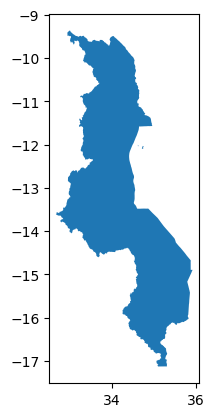

In [9]:
adm0.plot()

### Population

In [10]:
wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above
wp_rio = rio.open(wp_path)
pop_surf = rio.open(wp_path)

### Health Facilities (destinations)

In [11]:
hf_path = join(expanduser("~/OneDrive - WBG"), 'Health-Access-Metrics', 'data', 'MWI', 'HF_Malawi.xlsx')
df_hf = pd.read_excel(hf_path)
df_hf

,Facility Name,Village,GVH,TA,District,Region,Eastings,Northings,Datum,Facility Type,Controlling Agency,Name,Phone,Email,Cluster,Status,Date
0,CHITIPA DH,Mkombanyama,Mkombanyama,Mwawulambya,Chitipa,North,33.265889,-9.701577,WGS 84,Hospital,MoH,Dzinkambani Kambalame,991183141,dzinkambalame@gmail.com,Chitipa DH,Functional,2016-07-01
1,NGOYA,Mphala,Mwakawanga,Mwawulambya,Chitipa,North,33.293329,-9.617792,WGS 84,Health Post,MoH,Martha Mwanza,884254076,NaN,Chitipa DH,Functional,2016-07-01
2,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Outreach,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
3,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Village Clinic,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
4,KALIRA,Flyson,Mwanisenga,Mwawulambya,Chitipa,North,33.312223,-9.575143,WGS 84,Health Post,MoH,Jonathan Muyila,991818899,NaN,Chitipa DH,Functional,2016-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,MLOLO,Chipondeni,Chipondeni,Mlolo,Nsanje,South,35.152560,-16.419711,WGS 84,Health Post,MoH,Charlie Mateyu,881148416,NaN,Mlolo,Functional,2016-09-01
9494,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Outreach,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9495,KHANA,Khana,Gatoma,Mlolo,Nsanje,South,35.179200,-16.377098,WGS 84,Village Clinic,MoH,Caroline Allan,888601487,NaN,Mlolo,Functional,2016-09-01
9496,KANDODO,Gowoke,Gowoke,Mlolo,Nsanje,South,35.159567,-16.405433,WGS 84,Outreach,MoH,Charity Bramu,888595161,NaN,Mlolo,Functional,2016-09-01


Convert the HF from pandas.Dataframe to Geopandas.dataframe

In [12]:
geodf_hf = gpd.GeoDataFrame(
    df_hf, geometry=gpd.points_from_xy(df_hf.Eastings, df_hf.Northings), crs="EPSG:4326"
)

Clean the Geopandas df

In [13]:
geodf_hf = geodf_hf[['Facility Name', 'geometry']]
geodf_hf.loc[:, 'ID'] = df_hf.index
geodf_hf


,Facility Name,geometry,ID
0,CHITIPA DH,POINT (33.26589 -9.70158),0
1,NGOYA,POINT (33.29333 -9.61779),1
2,KALIRA,POINT (33.31222 -9.57514),2
3,KALIRA,POINT (33.31222 -9.57514),3
4,KALIRA,POINT (33.31222 -9.57514),4
...,...,...,...
9493,MLOLO,POINT (35.15256 -16.41971),9493
9494,KHANA,POINT (35.17920 -16.37710),9494
9495,KHANA,POINT (35.17920 -16.37710),9495
9496,KANDODO,POINT (35.15957 -16.40543),9496


### Flood extent

Here, we import Fathom flood data (.tif) of fluvial floods with different return periods. \
This data represent and mimic the climate impact on infrastructure and the disruption of the accessibility to health facilities.  

In [18]:
# Use rasterio to open the file
# flooded area:      999
# not-flooded area: -9999

fld_path = join(expanduser("R:/"), 'Data', 'GLOBAL','FLOOD_SSBN','v2_2019/malawi', 'fluvial_undefended', 'FU_1in5.tif')
fld_rio = rio.open(fld_path)
fld_rio.read(1)

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      dtype=float32)

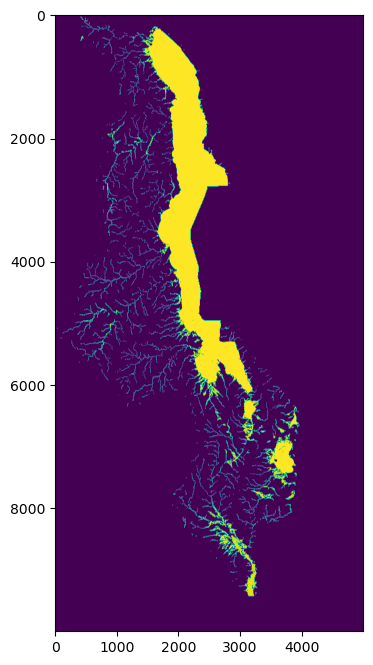

In [76]:
fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(fld_rio.read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

### Friction Surface

Process the travel cost surface from the Malaria Atlas Project, clip the raster to our region of interest.

In [28]:
# # Only the first time, clip the travel friction surface to the country of interest

# gfs_path = join(expanduser("R:/"), 'Data', 'GLOBAL/INFRA/FRICTION_2020', '2020_motorized_friction_surface.geotiff') # Download from link above
# gfs_rio = rio.open(gfs_path)
# out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
# rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

In [29]:
# Import the clipped friction surface

out_travel_surface = join(scratch_dir, 'data', f"travel_surface_motorized_{iso}.tif")
travel_surf = rio.open(out_travel_surface)

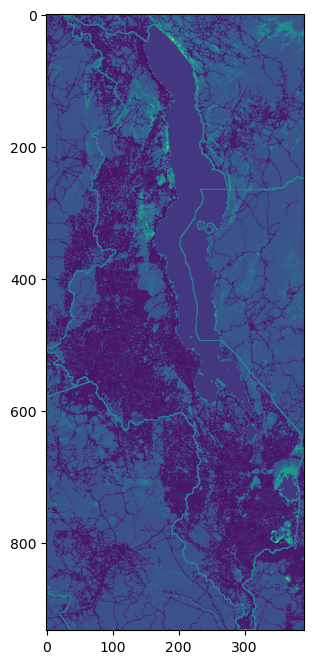

In [30]:
fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(travel_surf.read(1), norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

Align the population raster to the friction surface, ensuring that they have the same extent and resolution.

In [32]:
out_pop_surface_std = join(scratch_dir, 'data', "WP_2020_1km_STD.tif")
rMisc.standardizeInputRasters(pop_surf, travel_surf, out_pop_surface_std, resampling_type="nearest")

[array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32),
 {'driver': 'GTiff',
  'dtype': 'float32',
  'nodata': -99999.0,
  'width': 390,
  'height': 933,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.008333333333333333, 0.0, 32.66666666666666,
         0.0, -0.008333333333333333, -9.358333333333334)}]

### Origins

We prepare a standard grid using each cell from the 1km World Pop raster.

In [34]:
pop_surf = rio.open(out_pop_surface_std)
pop = pop_surf.read(1, masked=False)

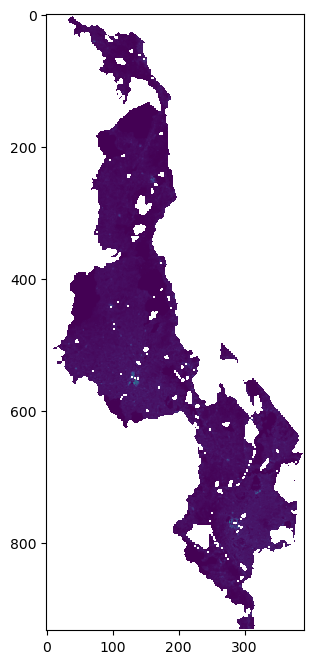

In [35]:
pop_copy = pop.copy()
pop_copy[pop_copy==0] = np.nan

fig, ax = plt.subplots(figsize=(6,8))
im = ax.imshow(pop_copy, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

### Origins

Prepare a standard grid using each cell from the 1km World Pop raster.

In [36]:
indices = list(np.ndindex(pop.shape))
xys = [Point(wp_rio.xy(ind[0], ind[1])) for ind in indices]
res_df = pd.DataFrame({
    'spatial_index': indices, 
    'xy': xys, 
    'pop': pop.flatten()
})
res_df['pointid'] = res_df.index
res_df

,spatial_index,xy,pop,pointid
0,"(0, 0)",POINT (32.67166655066495 -9.364166148664985),0.0,0
1,"(0, 1)",POINT (32.67249988399486 -9.364166148664985),0.0,1
2,"(0, 2)",POINT (32.67333321732477 -9.364166148664985),0.0,2
3,"(0, 3)",POINT (32.674166550654675 -9.364166148664985),0.0,3
4,"(0, 4)",POINT (32.67499988398458 -9.364166148664985),0.0,4
...,...,...,...,...
363865,"(932, 385)",POINT (32.99249988267934 -10.140832812196972),0.0,363865
363866,"(932, 386)",POINT (32.99333321600925 -10.140832812196972),0.0,363866
363867,"(932, 387)",POINT (32.994166549339155 -10.140832812196972),0.0,363867
363868,"(932, 388)",POINT (32.99499988266906 -10.140832812196972),0.0,363868


In [52]:
type(res_df)

pandas.core.frame.DataFrame